# CEBAMA: low-pH concrete against Callovo-Oxfordian clay rock (FEniCSx + GEMS)

Reproduces fenics-reaktoro `Demos/Cebama_Benchmark` with the four modules in
`FEniCSx_GEMS_Beginner` (two folders up). All settings are in `case.yaml`; the code cells
only run it and plot. Nothing needs editing.

A 0.30 m layer of low-pH concrete (pH 10.7) is in contact with COx clay rock (pH 7.1). The
clay pore water is held at the far end. Over 100 years the concrete pore water is
neutralised by diffusion into and out of the clay.

| Quantity | Original | `case.yaml` |
|---|---|---|
| Domain | 0–40.3 m, non-uniform (0.02 m near the interface) | 0–4 m, uniform 0.02 m (200 cells) |
| Zones | concrete (`cem-sol-min`) to 0.30 m, COx (`COx-sol-min`) beyond | `transport.zones` concrete / COx |
| Porosity | 0.04 / 0.18 (from the GEMS states) | `phi` per zone |
| Diffusion | flux $= \phi D_p \nabla c$, $D_p$ = 2.5e-11 / 1.44e-10 m²/s, same for all species | $D_e = \phi D_p$ per zone |
| Boundaries | left closed, right fixed at COx pore water | `no_flux` / `dirichlet`, `inlet: {right: COx}` |
| Time | $\Delta t$ = 3.154e5 s; reference profiles at 10 and 100 y | $\Delta t$ = 0.1 y, 100 y, profiles every 10 y |

## Transport

For every element (Al, C, Ca, Cl, Cx, Fe, H, K, Mg, Na, O, Opa, S, Si, Sol, Sr, Tra; charge not
transported), with $c_j$ in mol per m³ of pore water:

$$
\phi\,\frac{\partial c_j}{\partial t} = \frac{\partial}{\partial x}\Bigl(D_e\,\frac{\partial c_j}{\partial x}\Bigr),
\qquad D_e = \phi D_p .
$$

This is exactly the original weak form (`cebama.npswf`: one $D_p$ per material for all
species, weighted by porosity). Elements bound only in solids or exchangers (Sol, Cx, Opa)
have no dissolved part, so they do not move. `Tra` is a tracer initially in the concrete.

**Why 4 m and 0.1-year steps.** The diffusion length in COx after 100 years is
$\sqrt{D_p t}\approx 0.7$ m, so a 4 m column with the COx water fixed at its end behaves like
the original 40 m one over this period. Backward Euler is unconditionally stable, so
$\Delta t$ = 0.1 y (instead of 3.65 d) keeps the run to 1000 steps × 200 cells.

**Zones.** `transport.zones` splits the column into named parts; a cell belongs to a zone when
its centre lies in `[from, to)`, and the zone may set its own `phi` and `De`.
`chemistry.initial` then gives one recipe per zone name. At a zone interface the face
diffusivity is the harmonic mean $2D_{e,i}D_{e,i+1}/(D_{e,i}+D_{e,i+1})$, which keeps the flux
continuous.

## Chemistry

One GEMS system (18 elements, 115 species; phases `aq_gen`, `CSHExchanger`, `OpaExchanger`,
`Sol`). `cem-sol-min` and `COx-sol-min` share the same DCH; their DBR states, scaled to 1 dm³
of bulk, are the zone recipes. The pore-water fractions (0.04 and 0.18) are the porosities.
`Sol` is the bulk solid skeleton; the two exchanger phases hold the sorbed cations.

**`chemistry.start: warm`.** This large system does not always converge from a cold start
when pore water from the other zone arrives. With `warm`, every cell keeps its own GEMS engine
and starts each step from its own previous equilibrium (as the original code does). If that
fails, GEMS re-solves the cell's previous composition and approaches the new one in four
steps; then cold starts with scaled system sizes.

**`chemistry.on_failure: skip`.** If all of that fails, the cell is left unreacted for that
step (transported pore water, previous minerals); element totals are unchanged, so mass is
still conserved. Every skip is printed and written to `results/simulation.log`, with a total at
the end. A few skips at the interface are harmless; many mean the results there are unreliable.

## SNIA coupling (`coupling.py`)

Once per time step: (1) diffuse the dissolved element amounts, minerals fixed;
(2) `total = immobile + aqueous`; (3) GEMS equilibrium in every cell;
(4) check that the column inventory changed only by what crossed the boundaries.

## Settings

The file that is run:

In [17]:
print(open("case.yaml", encoding="utf-8").read())

# CEBAMA benchmark: low-pH concrete in contact with Callovo-Oxfordian clay rock
# (fenics-reaktoro Demos/Cebama_Benchmark), with the four modules two folders up.
# Run from this folder:  python ../../coupling.py case.yaml   (or Run.cmd, or the notebook)
#
# Original: 0-40.3 m non-uniform mesh, concrete 0-0.30 m, COx beyond, left closed,
# right held at COx pore water, one pore diffusion coefficient per material
# (concrete 2.5e-11, COx 1.44e-10 m2/s; flux = phi * Dp * grad c), dt = 3.154e5 s.
# Here: uniform 0.02 m cells on 0-4 m (the 100-year front stays within ~1 m),
# dt = 0.1 year, 100 years; profiles every 10 years (reference data at 10 and 100 y).
# chemistry.start: warm - each cell restarts GEMS from its own previous equilibrium.

# 1. chemistry.py: GEMS project, chemical conditions, and recipes.
chemistry:
  project: chemistry_data/cem-sol-min-dat.lst   # same DCH as COx-sol-min
  temperature: 298.15                  # K
  pressure: 100000                     # Pa
  aqueous_pha

## Run

Same as double-clicking `Run.cmd`.

In [18]:
import sys
!{sys.executable} ../../coupling.py case.yaml

[2026-09-24 16:42:17.343] [gems3k] [info] Home directory is /home/xi_b
step=0, time=0 s, balance=0.000e+00 mol/m2, chemistry=2.842e-11 mol/m3, water mismatch=0.00%
WARNING skipped: step=5, cell=14, x=0.29 m (GEMS did not converge)
WARNING skipped: step=6, cell=14, x=0.29 m (GEMS did not converge)
WARNING skipped: step=7, cell=14, x=0.29 m (GEMS did not converge)
WARNING skipped: step=8, cell=14, x=0.29 m (GEMS did not converge)
WARNING skipped: step=9, cell=14, x=0.29 m (GEMS did not converge)
WARNING skipped: step=10, cell=14, x=0.29 m (GEMS did not converge)
WARNING skipped: step=11, cell=14, x=0.29 m (GEMS did not converge)
WARNING skipped: step=13, cell=14, x=0.29 m (GEMS did not converge)
WARNING skipped: step=15, cell=14, x=0.29 m (GEMS did not converge)
WARNING skipped: step=26, cell=13, x=0.27 m (GEMS did not converge)
WARNING skipped: step=27, cell=13, x=0.27 m (GEMS did not converge)
WARNING skipped: step=32, cell=13, x=0.27 m (GEMS did not converge)
WARNING skipped: step=33,

## Results

`summary.txt` and the overview plot from `output.py`.

COMPLETED
Mode: coupled
Cells/states: 200; reference length: 4.0 m
Scheme: backward Euler, DG0 two-point cell flux (transport modes only)
Linear solver: preonly / lu
Final time: 3155760000.0 s; steps: 1000
Amounts: mol/m3 bulk; concentrations: mol/m3 pore water
Inventory and boundary exchange: mol/m2 (unit cross-sectional area)
Maximum balance error: 1.211696e-08 mol/m2
Maximum chemical element reconstruction error: 4.829914e-09 mol/m3
Maximum aqueous-volume/porosity mismatch: 0.028630%
GEMS initialisation: independent cold start for every equilibrium call
Final porosity range: 0.0399990949 to 0.180004974
Final De range: 9.99977372e-13 to 2.59207162e-11 m2/s
Porosity feedback: False
Diffusivity feedback: False
Limit: numerical demonstration, not experimental validation.
Limit: saturated pore volume is assumed; aqueous volume mismatch is diagnostic only.



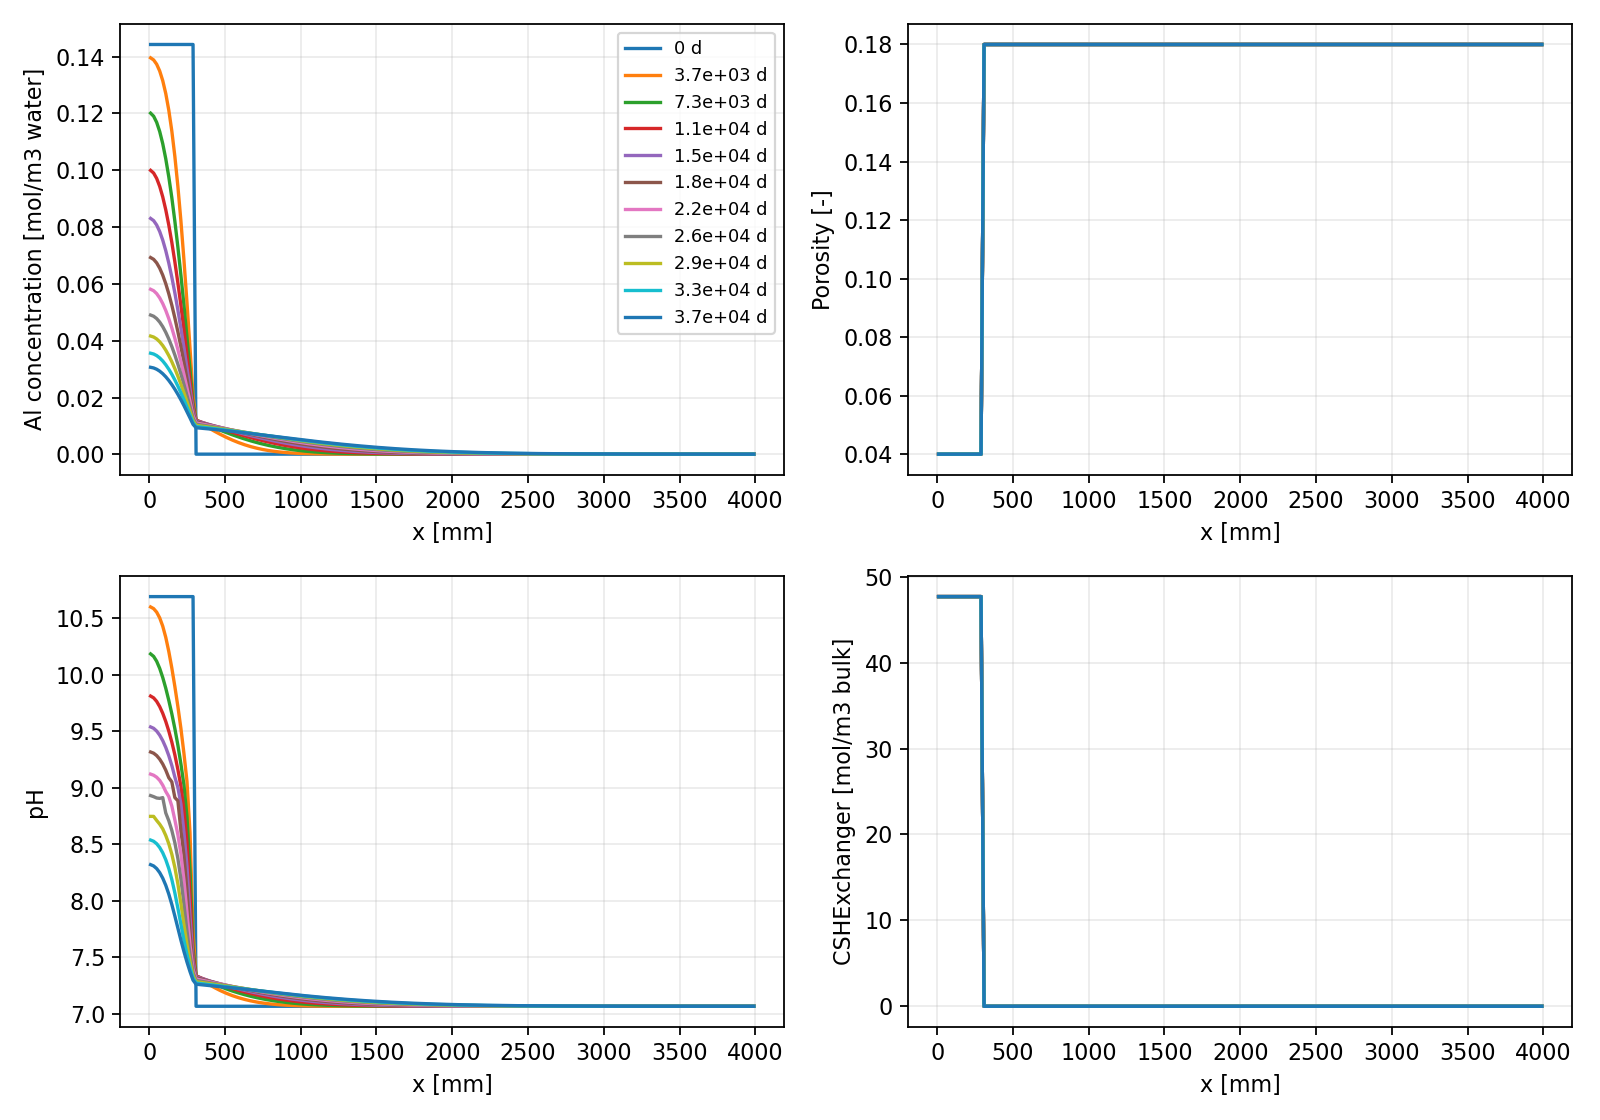

In [19]:
%matplotlib inline
import yaml
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd, matplotlib.pyplot as plt

case = yaml.safe_load(open("case.yaml"))
results = Path(case["output"]["folder"])
summary = (results / "summary.txt").read_text()
print(summary)
if not summary.startswith("COMPLETED"):
    raise RuntimeError("The run did not complete; the reason is printed above (also in results/failure.txt).")
display(Image(filename=str(results / "profiles.png")))
p = pd.read_csv(results / "profiles.csv")

## Comparison with the original: pH at 10 and 100 years

Lines: this model. Dots: original output (`reference/cebama_output__10y.txt`, `__100y.txt`).
Dashed: concrete / COx interface.

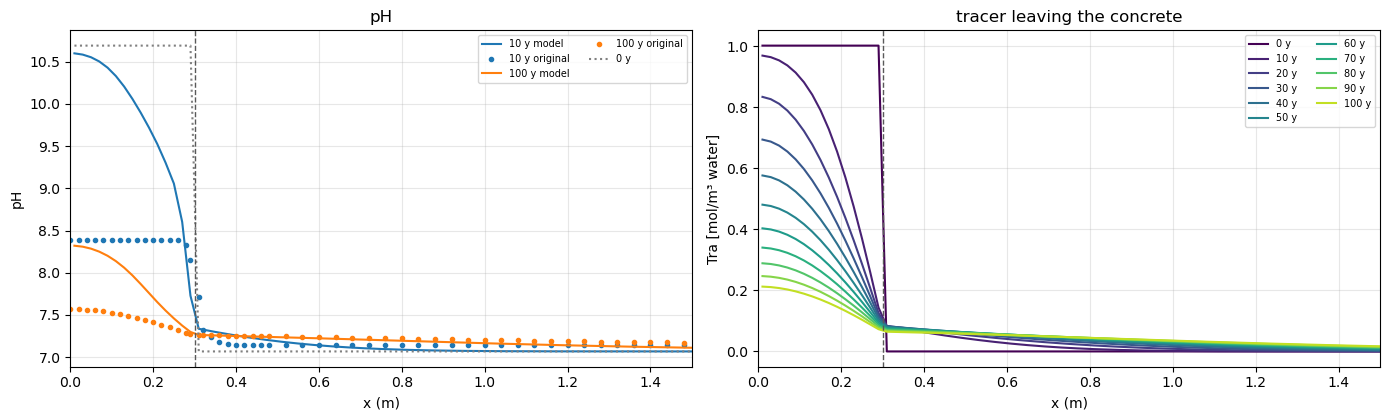

  10 y: max |pH model - original| on 0-1.5 m = 2.211
 100 y: max |pH model - original| on 0-1.5 m = 0.752


In [20]:
year = 365.25 * 86400
ref = {t: pd.read_csv(f"reference/cebama_output__{t}y.txt", skipinitialspace=True, usecols=[0, 1, 2],
                      names=["x", "porosity", "pH"], header=0) for t in (10, 100)}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
for k, t in enumerate((10, 100)):
    s = p[np.isclose(p["time_s"] / year, t)].sort_values("x_m")
    r = ref[t][ref[t]["x"] <= 1.5]
    axes[0].plot(s["x_m"], s["pH"], "-", color=f"C{k}", label=f"{t} y model")
    axes[0].plot(r["x"], r["pH"], "o", ms=3, color=f"C{k}", label=f"{t} y original")
s0 = p[p["time_s"] == 0].sort_values("x_m")
axes[0].plot(s0["x_m"], s0["pH"], ":", color="0.5", label="0 y")
axes[0].set(xlim=(0, 1.5), xlabel="x (m)", ylabel="pH", title="pH")
for k, (t, g) in enumerate(p.groupby("time_s")):
    g = g.sort_values("x_m")
    axes[1].plot(g["x_m"], g["Tra_c_mol_m3_water"], color=plt.cm.viridis(k / 11), label=f"{t / year:.0f} y")
axes[1].set(xlim=(0, 1.5), xlabel="x (m)", ylabel="Tra [mol/m³ water]", title="tracer leaving the concrete")
for ax in axes:
    ax.axvline(0.30, color="0.35", ls="--", lw=1); ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

for t in (10, 100):
    s = p[np.isclose(p["time_s"] / year, t)].sort_values("x_m")
    r = ref[t][ref[t]["x"] <= 1.5]
    diff = np.interp(r["x"], s["x_m"], s["pH"]) - r["pH"]
    print(f"{t:>4} y: max |pH model - original| on 0-1.5 m = {np.max(np.abs(diff)):.3f}")

## Differences to the original

| | Original | This model |
|---|---|---|
| Mesh | 0–40.3 m, non-uniform CG1, chemistry at nodes | 0–4 m, uniform DG0, chemistry per cell |
| Time step | 3.154e5 s | 0.1 year (backward Euler) |
| Chemistry | Reaktoro with the GEMS files | GEMS (xgems), one engine per cell, warm start |
| Diffusion | $\phi D_p$ per material, all species | same, per element |